In [514]:
print(1)

1


In [515]:
import pandas as pd
import numpy as np

# from google.colab import drive
# drive.mount('/content/gdrive')
# DATA_PATH = '/content/gdrive/MyDrive/REU/PROJECT/DATA/'
MN_PATH = "/home/jovyan/work/ner_congressional_records/"


In [516]:
mn_df = pd.read_csv(MN_PATH+"mn_transactors.csv")
mn_df.head()

/tmp/ipykernel_418/1267245001.py:1: DtypeWarning: Columns (5,10) have mixed types. Specify dtype option on import or set low_memory=False.
  mn_df = pd.read_csv(MN_PATH+"mn_transactors.csv")


,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN


<h1>Transactor types columms
</h1>

In [517]:
print("transactor types labels:", mn_df.transactor_type.unique())
print()
print("transactor type specific labels:", mn_df.transactor_type_specific.unique())


transactor types labels: [nan 'Individual' 'Organization' 'Self employed Retired']

transactor type specific labels: [nan 'Individual' 'Candidate' 'Party' 'Committee' 'Lobbyist'
 'Political Fund' 'Political Committee' 'Independent Expenditure Fund'
 'Independent Expenditure Committee' 'Ballot Fund' 'Ballot Committee']


<h3>LABEL DISTRIBUTION</h3>

In [518]:
mn_df['transactor_type'].isna().sum()

435878

In [519]:
mn_df.groupby(by='transactor_type', dropna=False).size()

transactor_type
Individual               372375
Organization             171726
Self employed Retired         1
NaN                      435878
dtype: int64

In [520]:
total = mn_df.groupby(by='transactor_type', dropna=False).size().sum()
total

979980

In [521]:
mn_df.groupby(by='transactor_type', dropna=False).size()/total

transactor_type
Individual               0.379982
Organization             0.175234
Self employed Retired    0.000001
NaN                      0.444783
dtype: float64

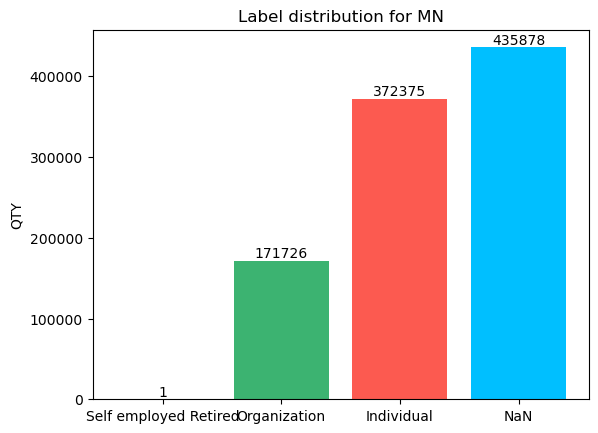

In [522]:
import matplotlib.pyplot as plt

def label_distribution(labels, groupby_df, colors):
    fig, ax = plt.subplots()
    ax.bar(labels, groupby_df)

    bars = ax.bar(labels, counts, color = colors)
    ax.bar_label(bars)

    ax.set_ylabel('QTY')
    ax.set_title('Label distribution for MN')

    # plt.savefig('az label distribution.png', transparent=True, bbox_inches = 'tight')
    plt.show()
    

mn_df_labels = ['Self employed Retired', 'Organization', 'Individual', 'NaN']
counts = mn_df.groupby(by='transactor_type', dropna=False).count()['id'].sort_values()
colors = [ 'mediumpurple', 'mediumseagreen', 'xkcd:coral', 'deepskyblue', 'xkcd:gold']

label_distribution(mn_df_labels, counts, colors)



In [523]:
mn_df = mn_df[mn_df['transactor_type'] != 'Self employed Retired']
mn_df.groupby(by='transactor_type', dropna=False).size()



transactor_type
Individual      372375
Organization    171726
NaN             435878
dtype: int64

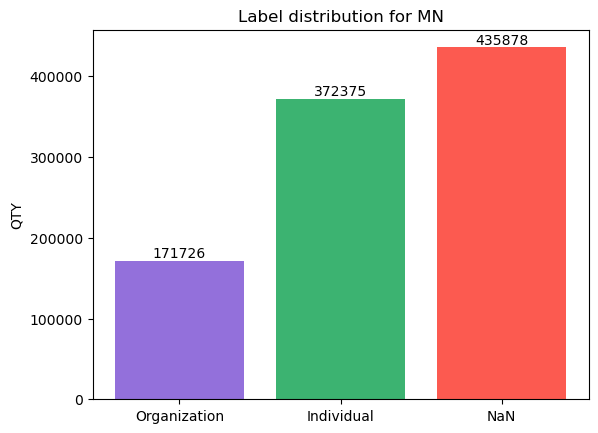

In [524]:
mn_df_labels = ['Organization', 'Individual', 'NaN']
counts = mn_df.groupby(by='transactor_type', dropna=False).count()['id'].sort_values()
colors = [ 'mediumpurple', 'mediumseagreen', 'xkcd:coral', 'deepskyblue', 'xkcd:gold']
label_distribution(mn_df_labels, counts, colors)

<h1>Names columns</h1>

In [ ]:
mn_df[['full_name', 'last_name', 'first_name', 'name_preferred', 'middle_name', 'name_suffix', 'name']]

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,NaN
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,NaN
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,NaN
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,NaN
4,Seiche,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
979975,NaN,NaN,NaN,NaN,NaN,NaN,MediaVista Group
979976,NaN,NaN,NaN,NaN,NaN,NaN,NARAL
979977,NaN,NaN,NaN,NaN,NaN,NaN,No Coast Workshop
979978,NaN,NaN,NaN,NaN,NaN,NaN,Screen Strategies Media


<h1>NaN values</h1>

In [526]:
""""transactor_type == NaN"""
mn_df[mn_df['transactor_type'].isna()]

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
979975,NaN,NaN,NaN,NaN,NaN,NaN,MN,49dc4d37-1c4e-43b1-83a6-96fbe87a2117,NaN,NaN,MediaVista Group
979976,NaN,NaN,NaN,NaN,NaN,NaN,MN,c0157442-e07a-4857-9d45-8b2ddaf33df9,NaN,NaN,NARAL
979977,NaN,NaN,NaN,NaN,NaN,NaN,MN,8b874ca9-eb02-4d0c-aa89-f5326dd1007f,NaN,NaN,No Coast Workshop
979978,NaN,NaN,NaN,NaN,NaN,NaN,MN,1ff81755-3515-4408-82fd-a69456ffa56d,NaN,NaN,Screen Strategies Media


In [527]:
""""transactor_type_specific == NaN"""
mn_df[mn_df['transactor_type_specific'].isna()].head()


,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN


In [528]:
# mn_df[mn_df[['transactor_type', 'transactor_type_specific']].isna().all(axis=1)]['transactor_type'].unique()
# mn_df[mn_df[['transactor_type', 'transactor_type_specific']].isna().all(axis=1)]['transactor_type_specific'].unique()

In [529]:
""""NaN == transactor_type == transactor_type_specific"""
mn_df[mn_df[['transactor_type', 'transactor_type_specific']].isna().all(axis=1)].head()


,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN


In [530]:
""""Nan == full_name == last_name == first_name == name_preferred == middle_name == name_suffix == name"""

mn_df[mn_df[['full_name', 'last_name', 'first_name', 'name_preferred', 'middle_name', 'name_suffix', 'name']].isna().all(axis=1)].head()


,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name
1051,NaN,NaN,NaN,NaN,NaN,NaN,MN,0fd662d6-dfb4-4f3f-b3c0-f784f7466202,NaN,NaN,NaN
2494,NaN,NaN,NaN,NaN,NaN,NaN,MN,84605e7f-d85c-4219-ba14-f6977044ebbe,NaN,NaN,NaN
2612,NaN,NaN,NaN,NaN,NaN,NaN,MN,0f518988-2070-44c7-8c69-a94f9a581cc8,NaN,NaN,NaN
4843,NaN,NaN,NaN,NaN,NaN,NaN,MN,dcfdd869-a8af-440d-ae81-70e4a7877c74,NaN,NaN,NaN
5926,NaN,NaN,NaN,NaN,NaN,NaN,MN,97d8d9b7-9c2c-4022-a7e5-3c846040e0f3,NaN,NaN,NaN


In [531]:
""""NaN == full_name == last_name == first_name == name_preferred == middle_name == name_suffix == name"""
mn_df[mn_df[['full_name', 'last_name', 'first_name', 'name_preferred', 'middle_name', 'name_suffix', 'name']].isna().all(axis=1)]


,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name
1051,NaN,NaN,NaN,NaN,NaN,NaN,MN,0fd662d6-dfb4-4f3f-b3c0-f784f7466202,NaN,NaN,NaN
2494,NaN,NaN,NaN,NaN,NaN,NaN,MN,84605e7f-d85c-4219-ba14-f6977044ebbe,NaN,NaN,NaN
2612,NaN,NaN,NaN,NaN,NaN,NaN,MN,0f518988-2070-44c7-8c69-a94f9a581cc8,NaN,NaN,NaN
4843,NaN,NaN,NaN,NaN,NaN,NaN,MN,dcfdd869-a8af-440d-ae81-70e4a7877c74,NaN,NaN,NaN
5926,NaN,NaN,NaN,NaN,NaN,NaN,MN,97d8d9b7-9c2c-4022-a7e5-3c846040e0f3,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
979454,NaN,NaN,NaN,NaN,NaN,NaN,MN,7e773e8c-7225-4cdd-88db-0d2c2202e84f,NaN,NaN,NaN
979853,NaN,NaN,NaN,NaN,NaN,NaN,MN,e485b7a6-7e58-4179-875f-0ec569e2d1a4,Organization,Political Committee,NaN
979854,NaN,NaN,NaN,NaN,NaN,NaN,MN,16ca4af0-451f-4437-82e4-9df51452eab5,Organization,Independent Expenditure Committee,NaN
979855,NaN,NaN,NaN,NaN,NaN,NaN,MN,f1d4e41a-6d8a-4ba6-9ddf-0940fc539b3d,Organization,Political Fund,NaN


In [532]:
mn_df[mn_df['name'].notna()]

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name
815047,NaN,NaN,NaN,NaN,NaN,NaN,MN,df551e2f-bdb1-4418-a0f4-effa74071b7b,NaN,NaN,"Miller, Jeremy Senate Committee"
815048,NaN,NaN,NaN,NaN,NaN,NaN,MN,f446a8ac-b591-41df-901d-5219bed431e3,NaN,NaN,Winona County RPM
815050,NaN,NaN,NaN,NaN,NaN,NaN,MN,addd5721-d313-4d85-8d73-2a3c8b7a4aa9,NaN,NaN,State of Minn
815051,NaN,NaN,NaN,NaN,NaN,NaN,MN,037f25d9-49f8-4243-adfb-0182cfbb28ba,NaN,NaN,"Jensen, Scott Mitchell Senate Committee"
815052,NaN,NaN,NaN,NaN,NaN,NaN,MN,23ea8a71-fc42-42e6-9022-4cfb1f5d60c0,NaN,NaN,61st Senate District RPM
...,...,...,...,...,...,...,...,...,...,...,...
979975,NaN,NaN,NaN,NaN,NaN,NaN,MN,49dc4d37-1c4e-43b1-83a6-96fbe87a2117,NaN,NaN,MediaVista Group
979976,NaN,NaN,NaN,NaN,NaN,NaN,MN,c0157442-e07a-4857-9d45-8b2ddaf33df9,NaN,NaN,NARAL
979977,NaN,NaN,NaN,NaN,NaN,NaN,MN,8b874ca9-eb02-4d0c-aa89-f5326dd1007f,NaN,NaN,No Coast Workshop
979978,NaN,NaN,NaN,NaN,NaN,NaN,MN,1ff81755-3515-4408-82fd-a69456ffa56d,NaN,NaN,Screen Strategies Media


<h3>DROP NaN</h3>

In [533]:
# DROP 
mn_df.dropna(subset=['full_name', 'last_name', 'first_name', 'name_preferred', 'middle_name', 'name_suffix', 'name'], how='all', inplace=True)

In [534]:
mn_df.shape

(978668, 11)

<h1>MERGE NAMES COLUMNS</h1>

In [535]:
#  MERGE NAMES COLUMNS
mn_df['merged_full_name'] = mn_df['name_suffix'].astype(str) + ' ' + mn_df['first_name'].astype(str) + ' ' + mn_df['middle_name'].astype(str) + ' ' + mn_df['last_name'].astype(str) + ' ' + mn_df['name_preferred'].astype(str) + ' ' + mn_df['name'].astype(str) + ' ' + mn_df['full_name'].astype(str)

In [536]:
mn_df['merged_full_name'] = mn_df['merged_full_name'].str.replace('nan', '', regex=False).str.strip()

In [537]:
mn_df['merged_full_name'] = mn_df['merged_full_name'].str.lower()
mn_df

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name,merged_full_name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN,not employed
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN,self employed sole proprietor - hotsprings hot...
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN,qwest communications
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN,minnesota state
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN,seiche
...,...,...,...,...,...,...,...,...,...,...,...,...
979975,NaN,NaN,NaN,NaN,NaN,NaN,MN,49dc4d37-1c4e-43b1-83a6-96fbe87a2117,NaN,NaN,MediaVista Group,mediavista group
979976,NaN,NaN,NaN,NaN,NaN,NaN,MN,c0157442-e07a-4857-9d45-8b2ddaf33df9,NaN,NaN,NARAL,naral
979977,NaN,NaN,NaN,NaN,NaN,NaN,MN,8b874ca9-eb02-4d0c-aa89-f5326dd1007f,NaN,NaN,No Coast Workshop,no coast workshop
979978,NaN,NaN,NaN,NaN,NaN,NaN,MN,1ff81755-3515-4408-82fd-a69456ffa56d,NaN,NaN,Screen Strategies Media,screen strategies media


<h3>DUPLICATE NAMES</h3>

In [538]:
mn_df['merged_full_name'].nunique()

143143

In [539]:
mn_df[mn_df['merged_full_name']== 'carlson, joel'].head()

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name,merged_full_name
1083,"Carlson, Joel",NaN,NaN,NaN,NaN,NaN,MN,292b1527-d83b-4ef9-8abd-99a6e43295a5,Individual,Lobbyist,NaN,"carlson, joel"
1977,"Carlson, Joel",NaN,NaN,NaN,NaN,NaN,MN,292b1527-d83b-4ef9-8abd-99a6e43295a5,Individual,Lobbyist,NaN,"carlson, joel"
4485,"Carlson, Joel",NaN,NaN,NaN,NaN,NaN,MN,292b1527-d83b-4ef9-8abd-99a6e43295a5,Individual,Lobbyist,NaN,"carlson, joel"
5674,"Carlson, Joel",NaN,NaN,NaN,NaN,NaN,MN,292b1527-d83b-4ef9-8abd-99a6e43295a5,Individual,Lobbyist,NaN,"carlson, joel"
6032,"Carlson, Joel",NaN,NaN,NaN,NaN,NaN,MN,292b1527-d83b-4ef9-8abd-99a6e43295a5,Individual,Lobbyist,NaN,"carlson, joel"


In [540]:
mn_df.groupby(by=['transactor_type', 'merged_full_name']).size().sort_values()

transactor_type  merged_full_name                       
Individual       (jeanne) poppe for the people committee      1
                 lord, richard c                              1
                 lord, susan                                  1
                 lorek, jay                                   1
                 lorence, drake w                             1
                                                           ... 
Organization     mn hospital pac                            503
                 ibew local 292 political education fund    539
                 xcel energy employees pac                  569
Individual       carlson, joel                              718
                 haselow, robert e, md                      747
Length: 75360, dtype: int64

In [541]:
# DUPLICATE NAMES
mn_df.groupby(by='merged_full_name').size().sort_values()

merged_full_name
levin, geney                         1
marnell, joseph p                    1
marna, taylor                        1
marlys, grafal                       1
marlow, richard k                    1
                                  ... 
carlson, joel                      719
haselow, robert e, md              748
self employed retired              750
mn dfl state central committee     824
usps                              1286
Length: 143143, dtype: int64

<h3>DROP DUPLICATE NAME</h3>

In [ ]:

# DROP DUPLICATE NAMES
mn_df.drop_duplicates(subset='merged_full_name', inplace=True)
mn_df.groupby(by='merged_full_name').size().sort_values()


merged_full_name
#8692 joel carlson legal research and government a    1
parker, kevin andrew                                  1
parker, kevin                                         1
parker, kathy j                                       1
parker, john                                          1
                                                     ..
hafiz, peter                                          1
hafiz, peter j                                        1
hafiz, richard                                        1
haffner, timothy j                                    1
ï monson, margot                                      1
Length: 143143, dtype: int64

In [543]:
mn_df

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name,merged_full_name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN,not employed
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN,self employed sole proprietor - hotsprings hot...
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN,qwest communications
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN,minnesota state
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN,seiche
...,...,...,...,...,...,...,...,...,...,...,...,...
979539,NaN,NaN,NaN,NaN,NaN,NaN,MN,fb8cfcbc-c0c7-457a-a0f3-a3b856fba8db,NaN,NaN,Alfred Mitchell Inc,alfred mitchell inc
979565,NaN,NaN,NaN,NaN,NaN,NaN,MN,978891f4-4411-4837-af04-95e669ef578d,NaN,NaN,"Karst, Franklin","karst, franklin"
979566,NaN,NaN,NaN,NaN,NaN,NaN,MN,0dd6ebcf-428c-44d0-933c-ff0ffdc3982f,NaN,NaN,Pinpoint Action LLC,pinpoint action llc
979969,NaN,NaN,NaN,NaN,NaN,NaN,MN,97d460e4-257f-464d-9b19-24aad6ba9707,NaN,NaN,Grand Rapids Herald,grand rapids herald


In [544]:
mn_df.groupby(by='transactor_type', dropna=False).size()

transactor_type
Individual      71780
Organization     2770
NaN             68593
dtype: int64

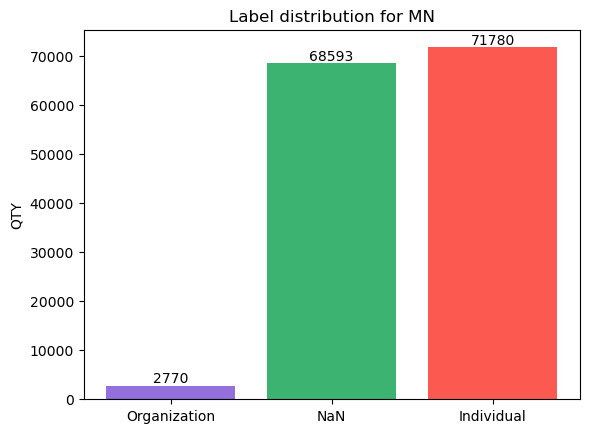

In [545]:
mn_df_labels = ['Organization', 'NaN', 'Individual']
counts = mn_df.groupby(by='transactor_type', dropna=False).count()['id'].sort_values()
colors = [ 'mediumpurple', 'mediumseagreen', 'xkcd:coral', 'deepskyblue', 'xkcd:gold']
label_distribution(mn_df_labels, counts, colors)

In [546]:
mn_df[mn_df['transactor_type'].isna()]

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name,merged_full_name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN,not employed
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN,self employed sole proprietor - hotsprings hot...
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN,qwest communications
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN,minnesota state
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN,seiche
...,...,...,...,...,...,...,...,...,...,...,...,...
979539,NaN,NaN,NaN,NaN,NaN,NaN,MN,fb8cfcbc-c0c7-457a-a0f3-a3b856fba8db,NaN,NaN,Alfred Mitchell Inc,alfred mitchell inc
979565,NaN,NaN,NaN,NaN,NaN,NaN,MN,978891f4-4411-4837-af04-95e669ef578d,NaN,NaN,"Karst, Franklin","karst, franklin"
979566,NaN,NaN,NaN,NaN,NaN,NaN,MN,0dd6ebcf-428c-44d0-933c-ff0ffdc3982f,NaN,NaN,Pinpoint Action LLC,pinpoint action llc
979969,NaN,NaN,NaN,NaN,NaN,NaN,MN,97d460e4-257f-464d-9b19-24aad6ba9707,NaN,NaN,Grand Rapids Herald,grand rapids herald


In [547]:
mn_df_annotated_data = mn_df.dropna(subset=['transactor_type']).copy()
mn_df_annotated_data


,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name,merged_full_name
833,"Rhode, Peter S",NaN,NaN,NaN,NaN,NaN,MN,b6d66efa-5b08-4e61-842a-6aa552f6be16,Individual,Individual,NaN,"rhode, peter s"
834,"Machayya, Mark",NaN,NaN,NaN,NaN,NaN,MN,0671e092-8ebd-4dcb-9de0-dd908955c649,Individual,Individual,NaN,"machayya, mark"
835,"LOVAASEN, TIM",NaN,NaN,NaN,NaN,NaN,MN,84fbdaf3-bcb8-469b-a846-94f1c7c609a5,Individual,Individual,NaN,"lovaasen, tim"
836,"Yang, Adam",NaN,NaN,NaN,NaN,NaN,MN,749ecab3-467e-488c-89af-6953af83d292,Individual,Candidate,NaN,"yang, adam"
837,"Elko, Thomas",NaN,NaN,NaN,NaN,NaN,MN,4799308b-161d-4730-b69d-f62164b25b37,Individual,Individual,NaN,"elko, thomas"
...,...,...,...,...,...,...,...,...,...,...,...,...
941633,Young Progressive Majority MN,NaN,NaN,NaN,NaN,NaN,MN,cf5c2780-a967-4e37-992c-effa28f5482e,Organization,Political Committee,NaN,young progressive majority mn
944391,"Kaiser, Jamie Senate Committee",NaN,NaN,NaN,NaN,NaN,MN,b45a97c0-2a0d-4e38-9b89-595d96d39729,Organization,NaN,NaN,"kaiser, jamie senate committee"
945886,"Cragg, Daniel Dist Court Committee",NaN,NaN,NaN,NaN,NaN,MN,0b08ad12-9df6-40bd-9e67-bacc285d23b8,Organization,NaN,NaN,"cragg, daniel dist court committee"
948410,"Anderson, Darrin House Committee",NaN,NaN,NaN,NaN,NaN,MN,a0a2e6ff-4e70-4554-ab4e-a9309571ee50,Organization,NaN,NaN,"anderson, darrin house committee"


In [548]:
mn_df_annotated_data.groupby(by='transactor_type', dropna=False).size()

transactor_type
Individual      71780
Organization     2770
dtype: int64

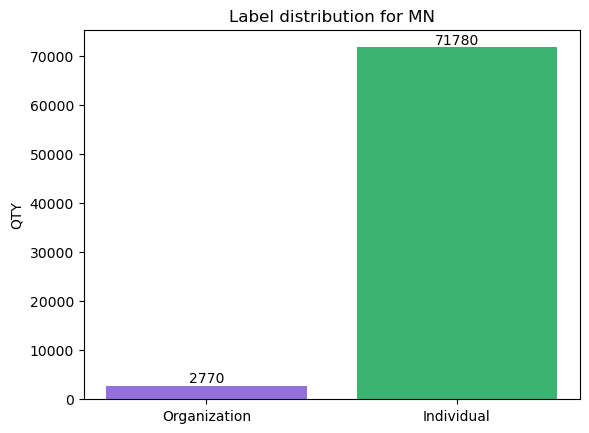

In [549]:
mn_df_labels = ['Organization', 'Individual',]
counts = mn_df_annotated_data.groupby(by='transactor_type', dropna=False).count()['id'].sort_values()
colors = [ 'mediumpurple', 'mediumseagreen', 'xkcd:coral', 'deepskyblue', 'xkcd:gold']
label_distribution(mn_df_labels, counts, colors)

In [554]:
non_annotated_data = mn_df[mn_df['transactor_type'].isna()].copy()
non_annotated_data

,full_name,last_name,first_name,name_preferred,middle_name,name_suffix,reported_state,id,transactor_type,transactor_type_specific,name,merged_full_name
0,Not Employed,NaN,NaN,NaN,NaN,NaN,MN,aaf1c118-9104-42f6-ac05-43a47d2ef232,NaN,NaN,NaN,not employed
1,Self employed Sole Proprietor - Hotsprings Hot...,NaN,NaN,NaN,NaN,NaN,MN,a6963a77-cec2-4cda-b347-a4f2fcfb09b0,NaN,NaN,NaN,self employed sole proprietor - hotsprings hot...
2,QWEST COMMUNICATIONS,NaN,NaN,NaN,NaN,NaN,MN,3c840d6a-869a-4153-8832-0d2926d0d066,NaN,NaN,NaN,qwest communications
3,Minnesota State,NaN,NaN,NaN,NaN,NaN,MN,0ea1612f-447b-4cb2-874f-cd984a4ba009,NaN,NaN,NaN,minnesota state
4,Seiche,NaN,NaN,NaN,NaN,NaN,MN,2bccc1e7-548b-4466-b64c-784f3224b128,NaN,NaN,NaN,seiche
...,...,...,...,...,...,...,...,...,...,...,...,...
979539,NaN,NaN,NaN,NaN,NaN,NaN,MN,fb8cfcbc-c0c7-457a-a0f3-a3b856fba8db,NaN,NaN,Alfred Mitchell Inc,alfred mitchell inc
979565,NaN,NaN,NaN,NaN,NaN,NaN,MN,978891f4-4411-4837-af04-95e669ef578d,NaN,NaN,"Karst, Franklin","karst, franklin"
979566,NaN,NaN,NaN,NaN,NaN,NaN,MN,0dd6ebcf-428c-44d0-933c-ff0ffdc3982f,NaN,NaN,Pinpoint Action LLC,pinpoint action llc
979969,NaN,NaN,NaN,NaN,NaN,NaN,MN,97d460e4-257f-464d-9b19-24aad6ba9707,NaN,NaN,Grand Rapids Herald,grand rapids herald
